# Financial Math

### Brownian Motion


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools
import os
import scipy.stats as stats

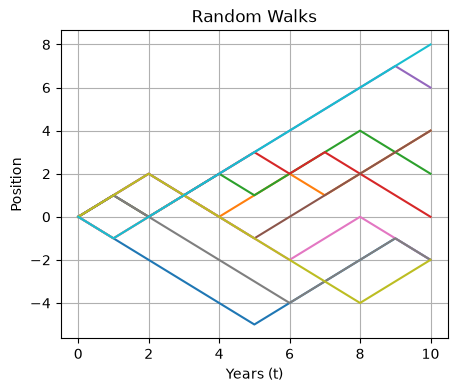

In [33]:
M = 10 # number of random walks
t = 10 # number of years

random_walk = [-1, 1]
steps = np.random.choice(random_walk, size=(M, t)).T
origin = np.zeros((1, M))
random_paths = np.concatenate((origin, steps), axis=0).cumsum(axis=0)

plt.figure(figsize=(5, 4))
plt.plot(random_paths)
plt.title('Random Walks')
plt.xlabel('Years (t)')
plt.ylabel('Position')
plt.grid()
plt.show()

## What just happened above?

That simulation is a **discrete random walk** — each step is either +1 or -1 with equal probability. This is the simplest possible model of randomness over time.

Real markets move in continuous time with normally distributed returns, not just ±1 steps. That brings us to **Standard Brownian Motion**.

## Standard Brownian Motion (Wiener Process)

A process $W(t)$ is a **Standard Brownian Motion** if:

1. $W(0) = 0$ — starts at zero
2. **Independent increments** — each step is independent of the past
3. **Normal increments** — $W(t) - W(s) \sim \mathcal{N}(0,\, t-s)$
4. **Continuous paths** — no jumps

Key insight: **variance grows linearly with time** — uncertainty compounds the further you look into the future.

We simulate it by summing small random shocks:
$$W(t) = \sum_{i=1}^{n} \epsilon_i \sqrt{\Delta t}, \quad \epsilon_i \sim \mathcal{N}(0,1)$$

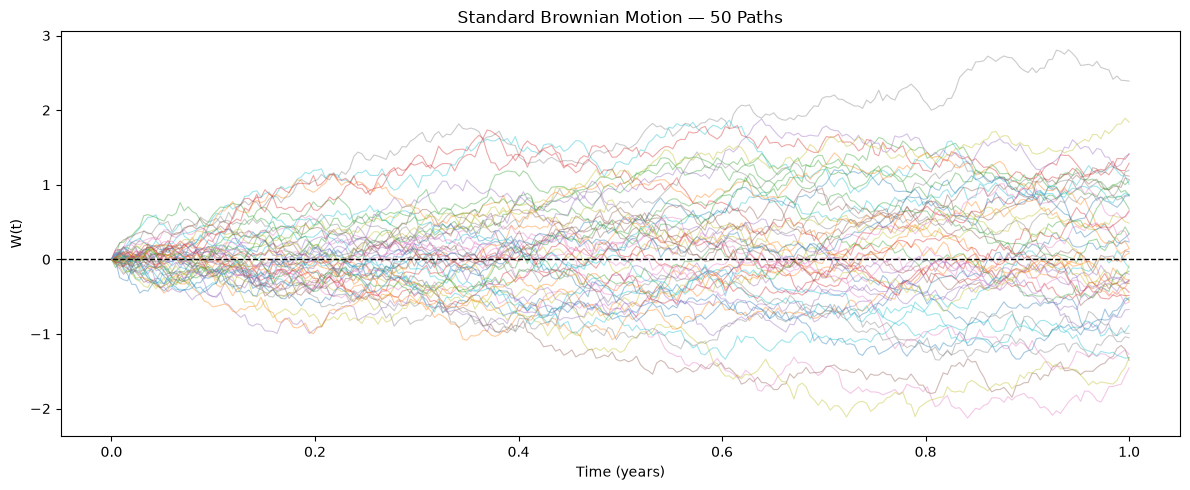

In [34]:
T  = 1.0         # 1 year
n  = 252         # trading days
dt = T / n
n_paths = 50

t_axis = np.linspace(0, T, n + 1)

plt.figure(figsize=(12, 5))
for _ in range(n_paths):
    shocks = np.random.normal(0, np.sqrt(dt), n)
    W = np.insert(np.cumsum(shocks), 0, 0)
    plt.plot(t_axis, W, alpha=0.4, linewidth=0.8)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title(f'Standard Brownian Motion — {n_paths} Paths')
plt.xlabel('Time (years)')
plt.ylabel('W(t)')
plt.tight_layout()
plt.show()

## Geometric Brownian Motion (GBM) — Stock Price Model

Plain Brownian motion can go **negative** — not useful for stock prices. **Geometric Brownian Motion** fixes this by modelling the **log-returns** as Brownian motion, keeping prices strictly positive.

This is the model behind **Black-Scholes** options pricing.

The GBM equation:
$$dS = \mu S \, dt + \sigma S \, dW$$

Which solves to:
$$S(t) = S_0 \exp\!\left(\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W(t)\right)$$

| Parameter | Meaning |
|---|---|
| $S_0$ | Starting price |
| $\mu$ | Drift — expected annual return (e.g. 10% → 0.10) |
| $\sigma$ | Volatility — std dev of annual returns (e.g. 20% → 0.20) |

The $-\frac{\sigma^2}{2}$ term is an **Itô correction** — it adjusts because the mean of log-returns is slightly less than the drift.

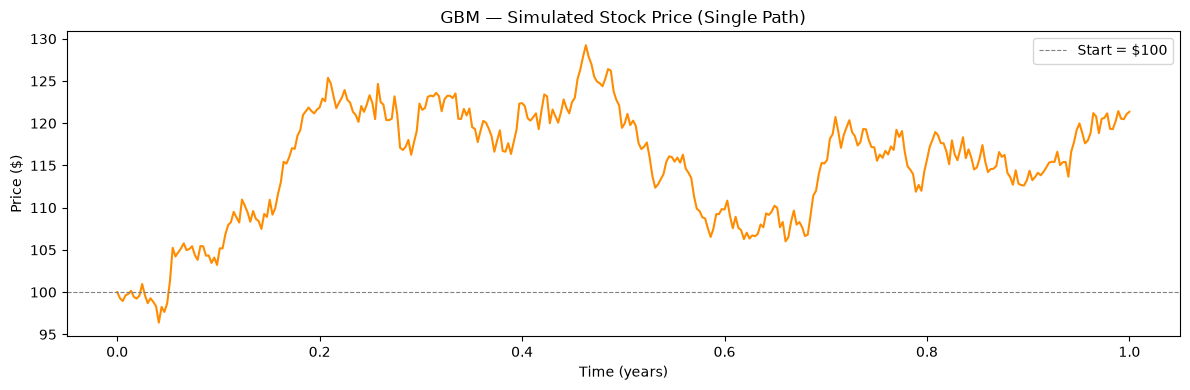

Final price:  $121.35
Total annualized return (CAGR): 21.4%


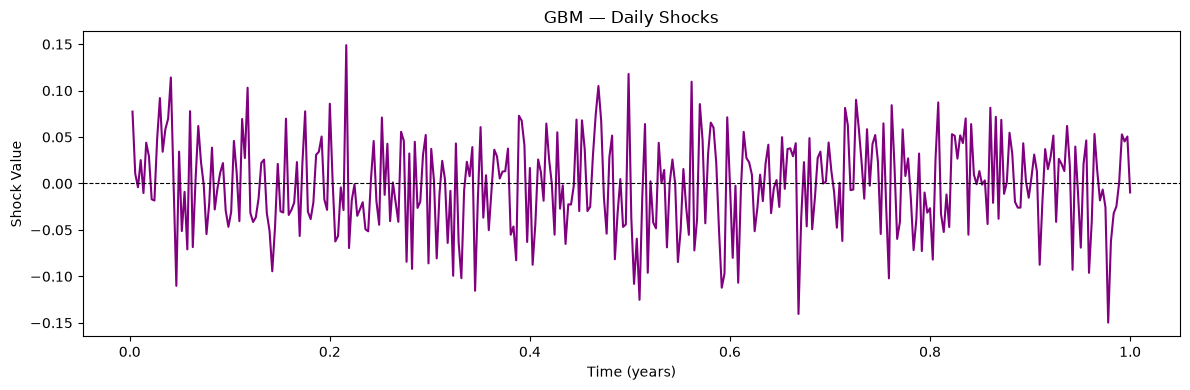

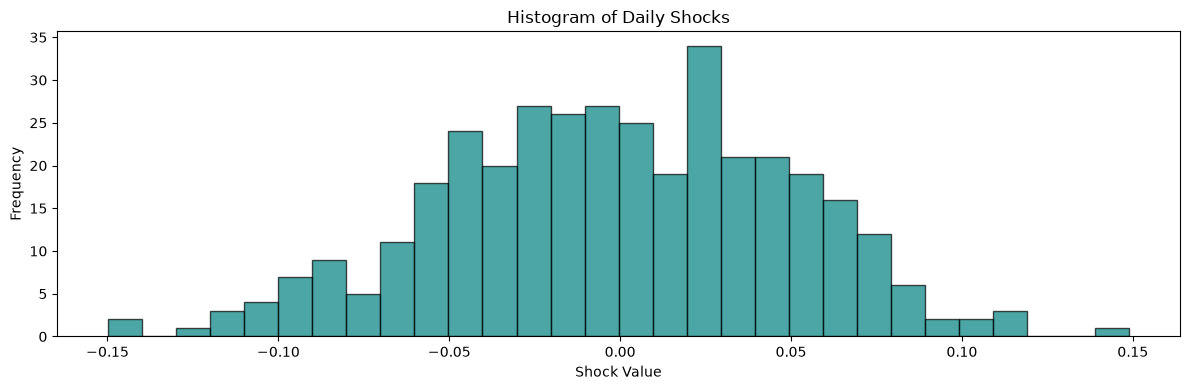

In [35]:
T = 1
n = 365
dt = T / n
t_axis = np.linspace(0, T, n + 1)
S0    = 100    # starting price ($)
mu    = 0.10   # 10% annual drift
sigma = 0.20   # 20% annual volatility

shocks = np.random.normal(0, np.sqrt(dt), n)
# shocks = np.zeros(n)  # fixed shock 
log_returns = (mu - 0.5 * sigma**2) * dt + sigma * shocks
S = S0 * np.exp(np.cumsum(log_returns))
S = np.insert(S, 0, S0)

# Plot the single GBM path
plt.figure(figsize=(12, 4))
plt.plot(t_axis, S, color='darkorange')
plt.axhline(S0, color='gray', linestyle='--', linewidth=0.8, label=f'Start = ${S0}')
plt.title('GBM — Simulated Stock Price (Single Path)')
plt.xlabel('Time (years)')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Final price:  ${S[-1]:.2f}')
print(f'Total annualized return (CAGR): {((S[-1]/S0 - 1))**(1/T)*100:.1f}%')
  
# shocks
plt.figure(figsize=(12, 4))
shocks = np.random.normal(0, np.sqrt(dt), n)
plt.plot(t_axis[1:], shocks, color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('GBM — Daily Shocks')
plt.xlabel('Time (years)')
plt.ylabel('Shock Value')
plt.tight_layout()
plt.show()

# Shock histogram
plt.figure(figsize=(12, 4))
plt.hist(shocks, bins=30, color='teal', edgecolor='black', alpha=0.7)
plt.title('Histogram of Daily Shocks')
plt.xlabel('Shock Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()  

## Monte Carlo Stock Price Simulation

Run GBM many times to get a **distribution of possible future prices**. This is how quants estimate:
- Probability of reaching a price target
- Option payoff distributions
- Portfolio Value at Risk (VaR)

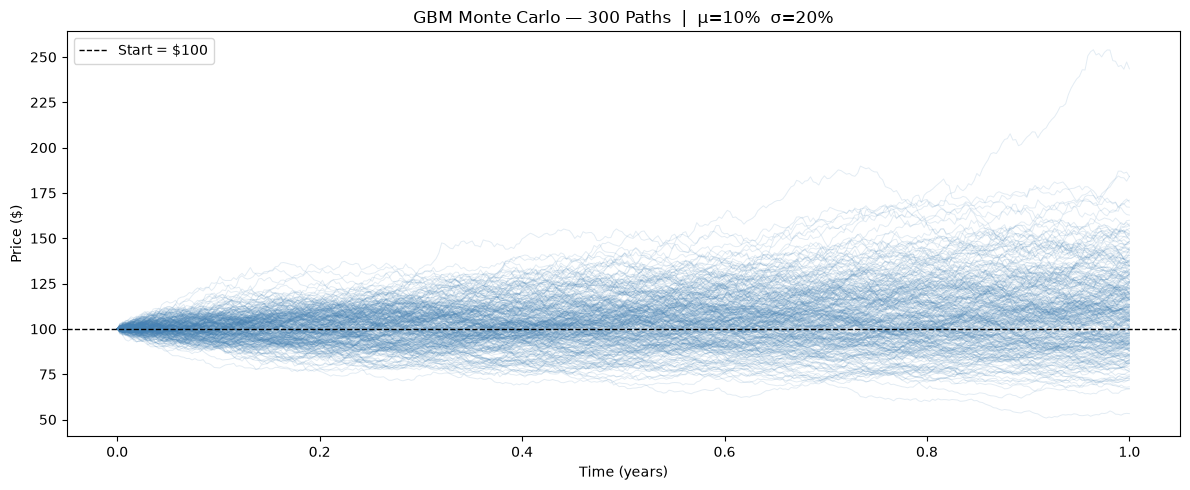

Mean final price:   $111.42
Median final price: $108.64
5th percentile:     $79.50  (worst 5% of outcomes)
95th percentile:    $152.15  (best 5% of outcomes)
Prob of gain:       65.7%


In [36]:
n_paths = 300
final_prices = []

plt.figure(figsize=(12, 5))
for _ in range(n_paths):
    shocks = np.random.normal(0, np.sqrt(dt), n)
    log_ret = (mu - 0.5 * sigma**2) * dt + sigma * shocks
    path = S0 * np.exp(np.cumsum(log_ret))
    path = np.insert(path, 0, S0)
    final_prices.append(path[-1])
    plt.plot(t_axis, path, alpha=0.15, linewidth=0.7, color='steelblue')

plt.axhline(S0, color='black', linestyle='--', linewidth=1, label=f'Start = ${S0}')
plt.title(f'GBM Monte Carlo — {n_paths} Paths  |  μ={mu:.0%}  σ={sigma:.0%}')
plt.xlabel('Time (years)')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

final_prices = np.array(final_prices)
print(f'Mean final price:   ${final_prices.mean():.2f}')
print(f'Median final price: ${np.median(final_prices):.2f}')
print(f'5th percentile:     ${np.percentile(final_prices,  5):.2f}  (worst 5% of outcomes)')
print(f'95th percentile:    ${np.percentile(final_prices, 95):.2f}  (best 5% of outcomes)')
print(f'Prob of gain:       {(final_prices > S0).mean()*100:.1f}%')

## Distribution of Final Prices

GBM produces a **log-normal distribution** of final prices — the log-returns are normal, but the prices themselves are skewed right. This means:
- Mean > Median (right skew)
- Prices can't go below zero
- Large upside moves are possible but rare

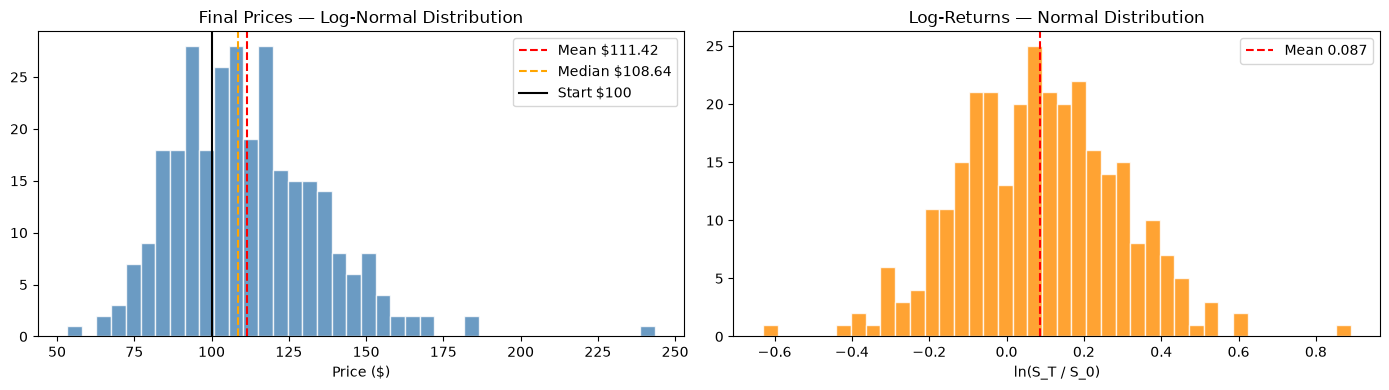

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(final_prices, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(final_prices.mean(),       color='red',    linestyle='--', label=f'Mean ${final_prices.mean():.2f}')
axes[0].axvline(np.median(final_prices),   color='orange', linestyle='--', label=f'Median ${np.median(final_prices):.2f}')
axes[0].axvline(S0, color='black', linewidth=1.5, label=f'Start ${S0}')
axes[0].set_title('Final Prices — Log-Normal Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].legend()

log_final = np.log(final_prices / S0)
axes[1].hist(log_final, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(log_final.mean(), color='red', linestyle='--', label=f'Mean {log_final.mean():.3f}')
axes[1].set_title('Log-Returns — Normal Distribution')
axes[1].set_xlabel('ln(S_T / S_0)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Why Is the Median Always ~$108? — The Math

Under GBM, the log of the final price is **normally distributed**:

$$\ln\!\left(\frac{S_T}{S_0}\right) \sim \mathcal{N}\!\left(\left(\mu - \frac{\sigma^2}{2}\right)T,\; \sigma^2 T\right)$$

The **median of a normal distribution equals its mean** (it's symmetric). So:

$$\text{median}\!\left[\ln\!\left(\frac{S_T}{S_0}\right)\right] = \left(\mu - \frac{\sigma^2}{2}\right)T$$

Exponentiating both sides:

$$\boxed{\text{Median}(S_T) = S_0 \cdot \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)T\right]}$$

The random term $\sigma W(T)$ **vanishes** because $W(T) \sim \mathcal{N}(0, T)$ is symmetric around 0 — its median is exactly 0. Only the deterministic part remains, so the median is the same every run no matter how many paths you simulate.

In [38]:
# Verify analytically vs simulation
analytical_median = S0 * np.exp((mu - 0.5 * sigma**2) * T)
analytical_mean   = S0 * np.exp(mu * T)

print('=== Analytical (exact) ===')
print(f'  Median = S0 * exp((μ - σ²/2) * T) = {analytical_median:.4f}')
print(f'  Mean   = S0 * exp(μ * T)           = {analytical_mean:.4f}')
print(f'  Difference (mean - median)          = {analytical_mean - analytical_median:.4f}')

print('\n=== From simulation (n=100,000 paths) ===')
big_shocks = np.random.normal((mu - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), (100_000, n))
big_finals = S0 * np.exp(big_shocks.sum(axis=1))
print(f'  Simulated median = {np.median(big_finals):.4f}')
print(f'  Simulated mean   = {big_finals.mean():.4f}')

print('\n=== Why mean > median? ===')
print('The mean is pulled up by rare extreme upside paths (right skew of log-normal).')
print(f'  Itô correction = σ²/2 = {0.5*sigma**2:.4f}  →  mean exceeds median by exp(σ²/2)-1 ≈ {(np.exp(0.5*sigma**2)-1)*100:.2f}%')

=== Analytical (exact) ===
  Median = S0 * exp((μ - σ²/2) * T) = 108.3287
  Mean   = S0 * exp(μ * T)           = 110.5171
  Difference (mean - median)          = 2.1884

=== From simulation (n=100,000 paths) ===
  Simulated median = 108.3944
  Simulated mean   = 110.5668

=== Why mean > median? ===
The mean is pulled up by rare extreme upside paths (right skew of log-normal).
  Itô correction = σ²/2 = 0.0200  →  mean exceeds median by exp(σ²/2)-1 ≈ 2.02%


---
## The Three Defining Properties of Brownian Motion

Standard Brownian Motion $W(t)$ is defined by three properties. Let's prove each one empirically.

### Property 1 — Continuous Paths

Brownian motion has no jumps — the path is continuous everywhere.

**Math:** Each increment $\Delta W = \epsilon\sqrt{\Delta t}$ where $\epsilon \sim \mathcal{N}(0,1)$. As $\Delta t \to 0$, the step size $\to 0$, so the path becomes continuous.

**Proof by simulation:** Show that the maximum single-step jump shrinks as we use more steps.

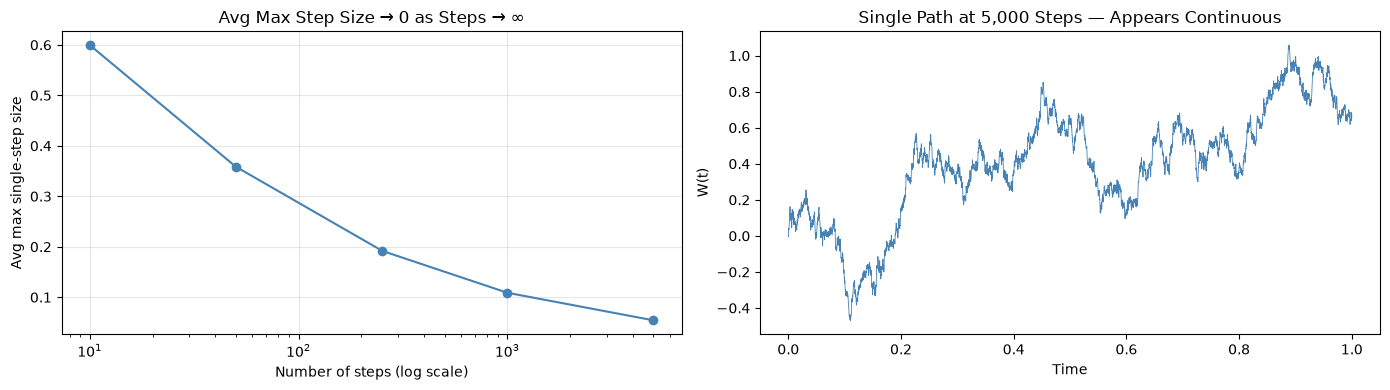

     10 steps → avg max jump = 0.59955
     50 steps → avg max jump = 0.35870
    252 steps → avg max jump = 0.19169
   1000 steps → avg max jump = 0.10883
   5000 steps → avg max jump = 0.05429


In [39]:
step_counts = [10, 50, 252, 1000, 5000]
avg_max_jumps = []

for steps in step_counts:
    _dt = T / steps
    # Run 1000 paths at each resolution, record max single-step jump
    shocks = np.random.normal(0, np.sqrt(_dt), (1000, steps))
    max_jumps = np.abs(shocks).max(axis=1)
    avg_max_jumps.append(max_jumps.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: max jump size vs step count
axes[0].plot(step_counts, avg_max_jumps, 'o-', color='steelblue')
axes[0].set_xscale('log')
axes[0].set_title('Avg Max Step Size → 0 as Steps → ∞')
axes[0].set_xlabel('Number of steps (log scale)')
axes[0].set_ylabel('Avg max single-step size')
axes[0].grid(True, alpha=0.3)

# Right: single path at high resolution (looks smooth)
fine_dt = T / 5000
fine_shocks = np.random.normal(0, np.sqrt(fine_dt), 5000)
fine_W = np.insert(np.cumsum(fine_shocks), 0, 0)
axes[1].plot(np.linspace(0, T, 5001), fine_W, linewidth=0.6, color='steelblue')
axes[1].set_title('Single Path at 5,000 Steps — Appears Continuous')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('W(t)')

plt.tight_layout()
plt.show()

for s, j in zip(step_counts, avg_max_jumps):
    print(f'  {s:>5} steps → avg max jump = {j:.5f}')

### Property 2 — Independent Increments

For any non-overlapping time intervals, the increments are **independent** — knowing what happened in the past tells you nothing about the future.

**Math:** If $s_1 < t_1 \leq s_2 < t_2$, then $[W(t_1) - W(s_1)]$ and $[W(t_2) - W(s_2)]$ are independent.

**Proof:** Compute the correlation between non-overlapping increments across many paths — it should be ~0.

Correlations between non-overlapping increments (should all be ≈ 0):
  corr( W(T/3)-W(0),    W(2T/3)-W(T/3) ) = -0.0042
  corr( W(2T/3)-W(T/3), W(T)-W(2T/3)   ) = -0.0043
  corr( W(T/3)-W(0),    W(T)-W(2T/3)   ) = -0.0054


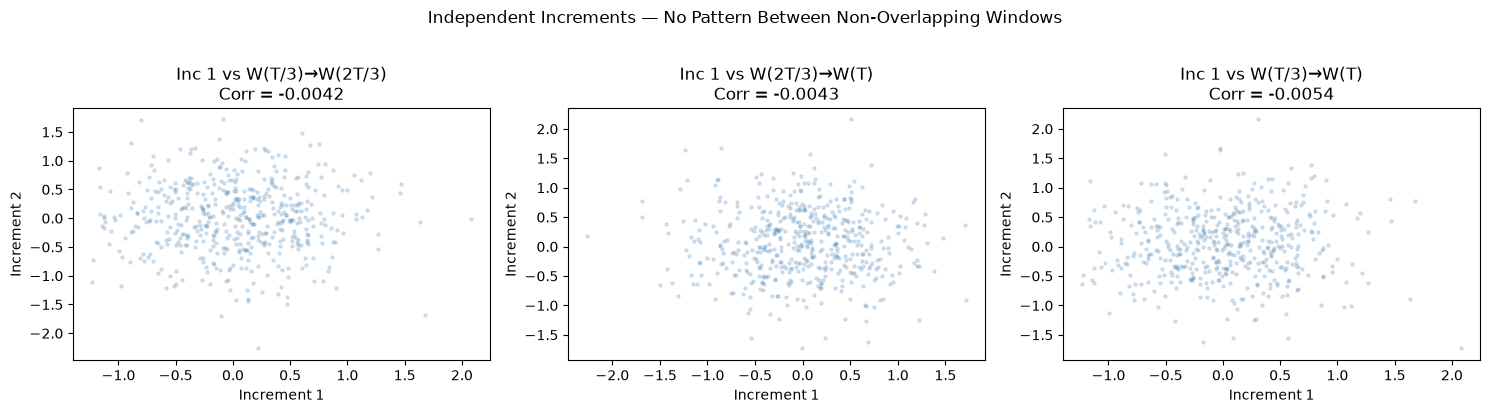

In [40]:
n_paths_test = 10_000
n_steps = 252
_dt = T / n_steps

# Simulate many paths
all_shocks = np.random.normal(0, np.sqrt(_dt), (n_paths_test, n_steps))
all_W = np.cumsum(all_shocks, axis=1)   # shape: (paths, steps)

# Split into three non-overlapping thirds
third = n_steps // 3
inc1 = all_W[:, third - 1]                    # W(T/3) - W(0)
inc2 = all_W[:, 2*third - 1] - all_W[:, third - 1]   # W(2T/3) - W(T/3)
inc3 = all_W[:, -1]          - all_W[:, 2*third - 1]  # W(T) - W(2T/3)

corr_12 = np.corrcoef(inc1, inc2)[0, 1]
corr_23 = np.corrcoef(inc2, inc3)[0, 1]
corr_13 = np.corrcoef(inc1, inc3)[0, 1]

print('Correlations between non-overlapping increments (should all be ≈ 0):')
print(f'  corr( W(T/3)-W(0),    W(2T/3)-W(T/3) ) = {corr_12:+.4f}')
print(f'  corr( W(2T/3)-W(T/3), W(T)-W(2T/3)   ) = {corr_23:+.4f}')
print(f'  corr( W(T/3)-W(0),    W(T)-W(2T/3)   ) = {corr_13:+.4f}')

# Scatter plot to visualise
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [(inc1, inc2, 'W(T/3)→W(2T/3)', corr_12),
         (inc2, inc3, 'W(2T/3)→W(T)',   corr_23),
         (inc1, inc3, 'W(T/3)→W(T)',    corr_13)]

for ax, (x, y, label, r) in zip(axes, pairs):
    ax.scatter(x[:500], y[:500], alpha=0.2, s=5, color='steelblue')
    ax.set_title(f'Inc 1 vs {label}\nCorr = {r:+.4f}')
    ax.set_xlabel('Increment 1')
    ax.set_ylabel('Increment 2')

plt.suptitle('Independent Increments — No Pattern Between Non-Overlapping Windows', y=1.02)
plt.tight_layout()
plt.show()

### Property 3 — Stationary & Normally Distributed Increments

This property has two parts bundled together.

---

#### Part A: Normally Distributed Increments

Any increment of Brownian motion over a time interval is normally distributed:

$$W(t+h) - W(t) \sim \mathcal{N}(0,\; h)$$

**Why normal?** Each increment is built from summing many tiny independent shocks ($\epsilon_i \sqrt{\Delta t}$). By the **Central Limit Theorem**, the sum of many small independent random variables converges to a normal distribution — regardless of what distribution each individual shock has.

**Why mean = 0?** Brownian motion has no drift — there's no tendency to go up or down. Each step is equally likely to be positive or negative.

**Why variance = h?** Variance accumulates linearly over time. If you take 252 steps each with variance $\Delta t$, total variance $= 252 \times \Delta t = T$. More time = more uncertainty.

---

#### Part B: Stationary

"Stationary" means the **distribution only depends on the length of the interval, not where it starts**.

A 1-month increment starting in January has the exact same distribution as a 1-month increment starting in October:

$$W(t+h) - W(t) \;\overset{d}{=}\; W(s+h) - W(s) \quad \text{for any } t, s$$

**Real-world analogy:** Imagine a fair coin. The probability of getting heads is 50% whether you flip it at 9am or 3pm. The *when* doesn't matter, only the *how long* (how many flips).

**Why this matters:** Brownian motion has no "memory" of where it's been. The future path looks statistically identical whether you start observing it on day 1 or day 100 — only the time elapsed matters.

---

#### Why Does This Break Down in Real Markets?

Real stocks **violate stationarity** in several ways:
- **Volatility clustering** — turbulent periods are followed by more turbulence (GARCH models fix this)
- **Fat tails** — extreme moves happen more often than a normal distribution predicts
- **Leverage effect** — volatility tends to spike when prices fall

This is why GBM is a starting point, not the final word. Models like **Heston** (stochastic volatility) and **jump-diffusion** were built to patch exactly these violations.

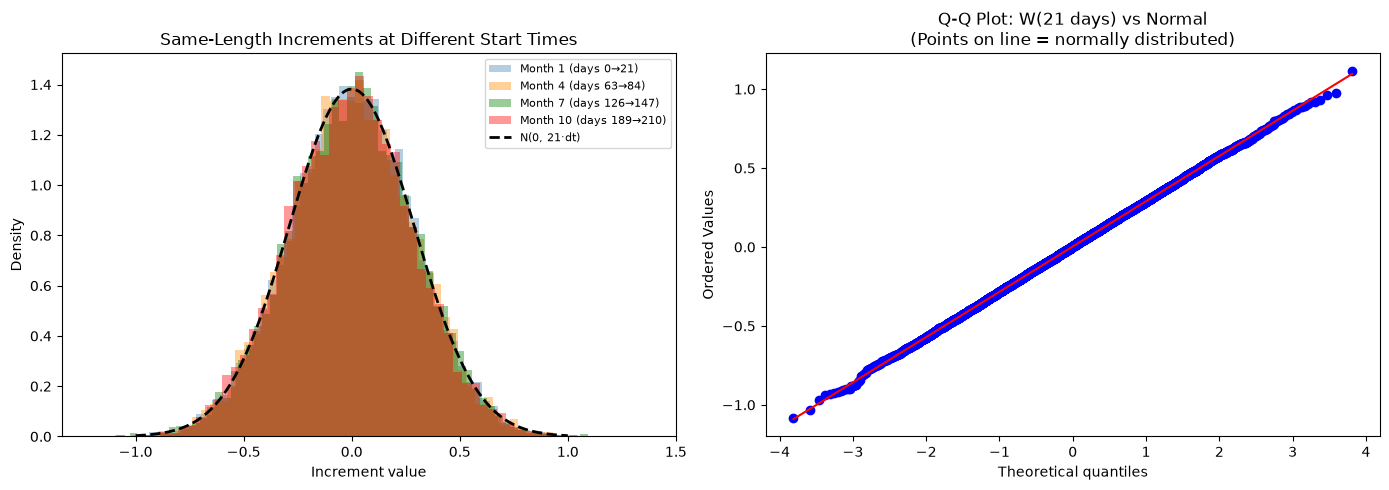

Theoretical: mean=0.0000, std=0.2887, var=0.0833

Month 1 (days 0→21)
  mean=+0.0030  std=0.2868  var=0.0822
Month 4 (days 63→84)
  mean=-0.0003  std=0.2918  var=0.0852
Month 7 (days 126→147)
  mean=+0.0026  std=0.2902  var=0.0842
Month 10 (days 189→210)
  mean=-0.0079  std=0.2900  var=0.0841


In [41]:
# Collect same-length (1-month = 21-day) increments starting at different times
window = 21    # 1 month of trading days
starts = [0, 63, 126, 189]   # start of each quarter
labels = ['Month 1 (days 0→21)', 'Month 4 (days 63→84)',
          'Month 7 (days 126→147)', 'Month 10 (days 189→210)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'darkorange', 'green', 'red']
stats_rows = []

for start, label, color in zip(starts, labels, colors):
    inc = all_W[:, start + window - 1] - (all_W[:, start - 1] if start > 0 else 0)
    axes[0].hist(inc, bins=60, alpha=0.4, label=label, color=color, density=True)
    stats_rows.append((label, inc.mean(), inc.std(), inc.std()**2))

# Overlay theoretical N(0, window*dt)
x = np.linspace(-1, 1, 300)
theoretical_std = np.sqrt(window * _dt)
axes[0].plot(x, stats.norm.pdf(x, 0, theoretical_std),
             'k--', linewidth=2, label=f'N(0, {window}·dt)')
axes[0].set_title('Same-Length Increments at Different Start Times')
axes[0].set_xlabel('Increment value')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# QQ plot for the first increment to confirm normality
stats.probplot(all_W[:, window - 1], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: W(21 days) vs Normal\n(Points on line = normally distributed)')

plt.tight_layout()
plt.show()

print(f'Theoretical: mean=0.0000, std={theoretical_std:.4f}, var={window*_dt:.4f}')
print()
for label, mean, std, var in stats_rows:
    print(f'{label}')
    print(f'  mean={mean:+.4f}  std={std:.4f}  var={var:.4f}')

### Summary — All Three Properties Verified

| Property | What we checked | Result |
|---|---|---|
| **Continuous paths** | Max step size as $\Delta t \to 0$ | Shrinks to zero ✓ |
| **Independent increments** | Correlation between non-overlapping windows | ≈ 0 across all pairs ✓ |
| **Stationary normal increments** | Histogram + Q-Q plot at different start times | Same $\mathcal{N}(0, h)$ every time ✓ |

Together these three properties **uniquely define** Standard Brownian Motion — any process satisfying all three is a Wiener process.

---
## Itô's Lemma — The Chain Rule of Stochastic Calculus

In ordinary calculus, the **chain rule** tells you how a function of a variable changes when that variable changes.

In stochastic calculus, **Itô's Lemma** does the same — but there's a correction term that doesn't exist in ordinary calculus. This correction is where the $-\frac{\sigma^2}{2}$ in GBM comes from.

**The core problem:** Standard calculus assumes $(dx)^2 \to 0$ for small $dx$. Brownian motion breaks this — its increments are so erratic that $(dW)^2$ does *not* vanish.

### Step 1 — The Key Fact: $(dW)^2 = dt$

For a standard Brownian motion, the **quadratic variation** over $[0, T]$ converges to $T$:

$$\sum_{i=0}^{n-1} \left[W(t_{i+1}) - W(t_i)\right]^2 \xrightarrow{n \to \infty} T$$

**Why?** Each increment $\Delta W_i \sim \mathcal{N}(0, \Delta t)$, so $\mathbb{E}[(\Delta W_i)^2] = \Delta t$. Summing $n$ steps: $\sum \mathbb{E}[(\Delta W_i)^2] = n \cdot \Delta t = T$.

In differential notation this is written: $\boldsymbol{(dW)^2 = dt}$

Compare with ordinary calculus where $(dt)^2 \to 0$. The table of stochastic multiplication rules:

| $\times$ | $dt$ | $dW$ |
|---|---|---|
| $dt$ | $0$ | $0$ |
| $dW$ | $0$ | $dt$ |

Everything second-order in $dt$ vanishes, *except* $(dW)^2 = dt$.

In [ ]:
# Numerically verify that sum of squared increments → T
T_qv = 1.0
step_sizes = [10, 50, 252, 1000, 5000, 20000]
n_trials   = 2000
results    = []

for n_steps in step_sizes:
    _dt = T_qv / n_steps
    increments = np.random.normal(0, np.sqrt(_dt), (n_trials, n_steps))
    quad_var   = (increments ** 2).sum(axis=1)   # sum of squared dW for each path
    results.append((n_steps, quad_var.mean(), quad_var.std()))

print(f'True value of T = {T_qv}')
print(f'{"Steps":>8}  {"Mean(ΣdW²)":>12}  {"Std":>8}')
print('-' * 34)
for n_steps, mean, std in results:
    print(f'{n_steps:>8}  {mean:>12.6f}  {std:>8.6f}')

# Plot convergence
ns   = [r[0] for r in results]
means = [r[1] for r in results]
stds  = [r[2] for r in results]

plt.figure(figsize=(10, 4))
plt.errorbar(ns, means, yerr=stds, fmt='o-', capsize=4, color='steelblue', label='Mean ± Std of ΣdW²')
plt.axhline(T_qv, color='red', linestyle='--', label=f'True T = {T_qv}')
plt.xscale('log')
plt.title('Quadratic Variation of Brownian Motion → T  (i.e. (dW)² = dt)')
plt.xlabel('Number of steps (log scale)')
plt.ylabel('Σ (ΔW)²')
plt.legend()
plt.tight_layout()
plt.show()

### Step 2 — Deriving Itô's Lemma via Taylor Expansion

Suppose $X(t)$ follows a general Itô process:

$$dX = a(X,t)\,dt + b(X,t)\,dW$$

We want to find how a smooth function $f(X, t)$ evolves. Start with the **Taylor expansion** to second order:

$$df = \frac{\partial f}{\partial t}dt + \frac{\partial f}{\partial X}dX + \frac{1}{2}\frac{\partial^2 f}{\partial X^2}(dX)^2 + \cdots$$

Substitute $dX = a\,dt + b\,dW$ and expand $(dX)^2$:

$$(dX)^2 = (a\,dt + b\,dW)^2 = a^2(dt)^2 + 2ab\,(dt)(dW) + b^2(dW)^2$$

Now apply the multiplication table from Step 1:

- $(dt)^2 = 0$
- $(dt)(dW) = 0$
- $(dW)^2 = dt$

So $(dX)^2 = b^2\,dt$. Substituting everything back:

$$df = \frac{\partial f}{\partial t}dt + \frac{\partial f}{\partial X}(a\,dt + b\,dW) + \frac{1}{2}\frac{\partial^2 f}{\partial X^2}b^2\,dt$$

Collecting $dt$ and $dW$ terms gives **Itô's Lemma**:

$$\boxed{df = \underbrace{\left(\frac{\partial f}{\partial t} + a\frac{\partial f}{\partial X} + \frac{1}{2}b^2\frac{\partial^2 f}{\partial X^2}\right)}_{\text{drift (deterministic)}}dt + \underbrace{b\frac{\partial f}{\partial X}}_{\text{diffusion (random)}}dW}$$

The **extra term** $\frac{1}{2}b^2\frac{\partial^2 f}{\partial X^2}$ has no analogue in ordinary calculus. It arises purely because $(dW)^2 = dt \neq 0$.

### Step 3 — Apply to GBM: Derive the Closed-Form Solution

GBM is defined by:
$$dS = \mu S\,dt + \sigma S\,dW$$

Here $a = \mu S$, $b = \sigma S$. We can't integrate this directly because $S$ is on the right-hand side.

**Trick:** Apply Itô's Lemma to $f(S) = \ln(S)$.

Compute the required partial derivatives:

$$\frac{\partial f}{\partial t} = 0, \qquad \frac{\partial f}{\partial S} = \frac{1}{S}, \qquad \frac{\partial^2 f}{\partial S^2} = -\frac{1}{S^2}$$

Substitute into Itô's Lemma:

$$d(\ln S) = \left(0 + \mu S \cdot \frac{1}{S} + \frac{1}{2}\sigma^2 S^2 \cdot \left(-\frac{1}{S^2}\right)\right)dt + \sigma S \cdot \frac{1}{S}\,dW$$

$$d(\ln S) = \left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma\,dW$$

This is now a simple SDE with **constant coefficients** — we can integrate directly:

$$\int_0^T d(\ln S) = \left(\mu - \frac{\sigma^2}{2}\right)\int_0^T dt + \sigma\int_0^T dW$$

$$\ln S(T) - \ln S_0 = \left(\mu - \frac{\sigma^2}{2}\right)T + \sigma W(T)$$

Exponentiating both sides:

$$\boxed{S(T) = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)T + \sigma W(T)\right]}$$

This is the exact closed-form solution to GBM. The $-\frac{\sigma^2}{2}$ **Itô correction** is not a fudge factor — it falls directly out of the second-derivative term in Itô's Lemma.

In [ ]:
# Verify: simulate GBM two ways and confirm they agree
#   Method A — Euler-Maruyama (step by step using the SDE: dS = μS dt + σS dW)
#   Method B — Closed form    (direct formula derived above via Itô's Lemma)

np.random.seed(0)
S0_ito = 100
mu_ito = 0.10
sig    = 0.20
T_ito  = 1.0
n_ito  = 252
dt_ito = T_ito / n_ito

n_paths_ito = 5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(n_paths_ito):
    shocks = np.random.normal(0, np.sqrt(dt_ito), n_ito)

    # Method A: Euler-Maruyama (discretise the SDE directly)
    S_euler = np.zeros(n_ito + 1)
    S_euler[0] = S0_ito
    for j, dw in enumerate(shocks):
        S_euler[j+1] = S_euler[j] + mu_ito * S_euler[j] * dt_ito + sig * S_euler[j] * dw

    # Method B: Closed form (Itô's Lemma solution)
    log_inc  = (mu_ito - 0.5 * sig**2) * dt_ito + sig * shocks
    S_closed = S0_ito * np.exp(np.cumsum(log_inc))
    S_closed = np.insert(S_closed, 0, S0_ito)

    t_axis_ito = np.linspace(0, T_ito, n_ito + 1)
    color = plt.cm.tab10(i)
    axes[0].plot(t_axis_ito, S_euler,  color=color, linewidth=1.2, label=f'Path {i+1}' if i == 0 else '')
    axes[1].plot(t_axis_ito, S_closed, color=color, linewidth=1.2)

axes[0].set_title('Method A: Euler-Maruyama\n(Discrete SDE: dS = μS dt + σS dW)')
axes[1].set_title("Method B: Itô's Lemma Closed Form\n(S(T) = S₀ exp[(μ-σ²/2)T + σW(T)])")
for ax in axes:
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Price ($)')
    ax.axhline(S0_ito, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Same random shocks, same result — Itô\'s Lemma gives the exact solution', y=1.01)
plt.tight_layout()
plt.show()

# Quantify the difference between the two methods
np.random.seed(1)
all_shocks = np.random.normal(0, np.sqrt(dt_ito), (10_000, n_ito))

# Euler finals
S_e = np.full(10_000, float(S0_ito))
for j in range(n_ito):
    S_e = S_e + mu_ito * S_e * dt_ito + sig * S_e * all_shocks[:, j]

# Closed-form finals
S_c = S0_ito * np.exp(((mu_ito - 0.5*sig**2)*dt_ito + sig*all_shocks).sum(axis=1))

print('Final price comparison (10,000 paths):')
print(f'  Euler-Maruyama mean:  ${S_e.mean():.4f}')
print(f'  Closed-form mean:     ${S_c.mean():.4f}')
print(f'  Mean absolute error:  ${np.abs(S_e - S_c).mean():.4f}  (small because dt is small)')

### Itô's Lemma — Summary

| Step | What we showed |
|---|---|
| $(dW)^2 = dt$ | Brownian motion's quadratic variation is non-zero — proven numerically |
| Taylor expansion | Adding the $(dX)^2$ term to the chain rule gives Itô's Lemma |
| Apply to $\ln(S)$ | Transforms GBM from a nonlinear SDE into a directly integrable equation |
| Closed form | $S(T) = S_0 \exp\!\left[(\mu - \frac{\sigma^2}{2})T + \sigma W(T)\right]$ |
| Itô correction | The $-\frac{\sigma^2}{2}$ is not arbitrary — it is the curvature cost of applying a nonlinear function ($\ln$) to a noisy process |

**Intuition for the correction:** When you apply a concave function like $\ln$ to a random variable, Jensen's inequality says $\mathbb{E}[\ln(S)] < \ln(\mathbb{E}[S])$. The $-\frac{\sigma^2}{2}$ term captures exactly this gap — the higher the volatility, the bigger the correction.

## Key Takeaways

| Concept | What it means |
|---|---|
| **Random Walk** | Discrete ±1 steps — building block of Brownian motion |
| **Standard Brownian Motion** | Continuous random walk, variance = time |
| **Geometric Brownian Motion** | Keeps prices positive; models log-returns as Brownian |
| **Drift (μ)** | Expected direction / annual return |
| **Volatility (σ)** | Amount of randomness / uncertainty |
| **Monte Carlo** | Run many paths to get a distribution of outcomes |
| **Log-normal prices** | Stock prices are log-normally distributed under GBM |
